In [1]:
#1A.2
import numpy as np
theta = np.radians(55)
ux = np.cos(theta)
uy = np.sin(theta)
vx = np.cos(theta+np.pi/2)
vy = np.sin(theta+np.pi/2)
print(ux,uy,vx,vy)

0.5735764363510462 0.8191520442889918 -0.8191520442889916 0.5735764363510464


In [2]:
#1A.3
import numpy as np
theta = np.radians(140) 
r = np.array([-3, 3])
u = np.array([np.cos(-theta),np.sin(-theta)])
v = np.array([np.cos(-theta+np.pi/2),np.sin(-theta+np.pi/2)])

magu = np.linalg.norm(u)
magv = np.linalg.norm(v)

unitu = u/magu
unitv = v/magv

ru = np.dot(r,unitu)*unitu #投影向量的求法
rv = np.dot(r,unitv)*unitv

print(np.linalg.norm(ru),np.linalg.norm(rv)) #此处为绝对值，记得的看一下方向确定符号

0.3697705002973153 4.226496158416552


In [3]:
#1A.4
import numpy as np
from scipy.optimize import fsolve
a = np.array([3, 1])
c_dot_a = -4
c_dot_b = 1

b = np.array([-1,3]) #要随着a变动,需要自己读图看一下数字和正负号

def eq(vars):
    x,y = vars
    c = np.array([x,y])
    eq1 = np.dot(c,a)-c_dot_a
    eq2 = np.dot(c,b)-c_dot_b
    return[eq1,eq2]
ig = [1,1]
ans = fsolve(eq,ig)
print(ans)

ModuleNotFoundError: No module named 'scipy'

In [ ]:
#1A.5
import numpy as np

theta = np.radians(45)
rOQ = np.array([5, 2,  0])
rQP = np.array([-3, -5, 0])

u = np.array([np.cos(-theta),np.sin(-theta),0]) #注意角度的旋转方向，theta前可能有正负
v = np.array([np.cos(-theta+np.pi/2),np.sin(-theta+np.pi/2),0])

magu = np.linalg.norm(u)
magv = np.linalg.norm(v)

unitu = u/magu
unitv = v/magv #unitu和上面的u是相同的，unitv和上面的v也是相同的,多写了一步，脑子抽了

ru = np.dot(rOQ+rQP,unitu)*unitu
rv = np.dot(rOQ+rQP,unitv)*unitv

print(np.linalg.norm(ru),np.linalg.norm(rv)) #同样注意正负号

3.535533905932738 0.7071067811865477


In [ ]:
#1A.6
import numpy as np

Px = 2
Py = -3
v = np.array([8,-8])

P = np.array([Px,Py])

r = P #er
u = np.array([-Py,Px]) #ethta

unitu = -u/np.linalg.norm(u) #ethta
unitr = r/np.linalg.norm(r) #er

pe = np.dot(v,unitu)*unitu
pr = np.dot(v,unitr)*unitr
print(pe,pr)

[1.84615385 1.23076923] [ 6.15384615 -9.23076923]


In [ ]:
#1B.3
import numpy as np
w = np.array([0,0,4])
r = np.array([-3,4,0])
rt = np.array([5,1,0])

v = np.cross(w,r)
print(v)

[-16 -12   0]


In [ ]:
#1B.5
import numpy as np
from scipy.optimize import fsolve

a = np.array([ 3, -4,  0])
bLength = 2.000
theta = 1.047 # in radians

def equations(vars):
    x,y = vars
    b = np.array([x,y,0])
    eq1 = np.dot(a,b) - np.linalg.norm(a)*np.linalg.norm(b)*np.cos(theta)
    eq2 = x**2+y**2 - bLength**2
    return [eq1,eq2]
ig = [1,1]
ans = fsolve(equations,ig)
print(ans)


[1.98568787 0.23883821]


In [ ]:
import numpy as np
from scipy.optimize import fsolve
rij = np.array([4.716, 5.311])
ruv = np.array([6.643, -2.513])

def equations(vars):
    theta1,theta2 = vars
    eq1 = ruv[0]*np.cos(theta1) - ruv[1]*np.sin(theta1) - rij[0]
    eq2 = ruv[0]*np.sin(theta2) + ruv[1]*np.cos(theta2) - rij[1]
    return [eq1,eq2]
ig = [2,1]
ans = fsolve(equations,ig)
print(ans)

[1.20629866 1.20635374]


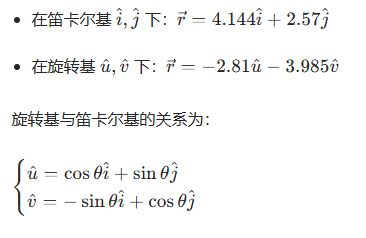

In [ ]:
# 2A.3
from sympy import *

t = symbols('t', real = True)

r = Matrix([-3*cos(t), 3*t**2, 3*exp(3*t)])
t_v = 2
v = diff(r,t)
v_val = v.subs(t,t_v)
v_val = v_val.norm().evalf()
print(v_val)

3630.87999613532


In [ ]:
#2A.4
import numpy as np
from sympy import *

t = symbols('t', real = True)

v = Matrix([-3*t**2 - 2*t + 3, t**2 - 3*t - 3, 0])
t_v = 3

r = integrate(v,t).subs(t,t_v).norm().evalf()
print(r)

30.1869176962472


$HW2A.5$  
$\dot{\hat{e}}_r = \dot{\theta}\hat{e}_\theta$  
$\dot{\hat{e}}_\theta = -\dot{\theta}\hat{e}_r$  

In [ ]:
# 2A.7
import numpy as np
from sympy import *

theta = symbols('theta')

r = sin(3*theta + 4) + 3
theta_v = 4 # in radians
omegaz = -1
alphaz = 3

v = r.diff(theta)

vval = (v.subs(theta,theta_v)*omegaz).evalf()
aval = (v.diff(theta).subs(theta,theta_v)*omegaz**2 + (v.subs(theta,theta_v)*alphaz)).evalf()

print(vval,aval)

2.87297844097015 -6.02780547292487


In [ ]:
# 2A.8 & 2A.10
import numpy as np
from sympy import *

theta = symbols('theta')

r = 3 - sin(4*theta + 1)
theta_v = -4 # in radians
omegaz = -2

r1 = r.diff(theta)
er = r1.subs(theta,theta_v)*omegaz
et = r.subs(theta,theta_v)*omegaz

i = (np.cos(theta_v)*er - np.sin(theta_v)*et).evalf()
j = (np.sin(theta_v)*er + np.cos(theta_v)*et).evalf()
print(i,j)

9.49761515674507 0.172505057214800


In [ ]:
#2B.2
import numpy as np

x = -4
y = -5
z = 1
omega = np.array([-1,  2, -2])

r = np.array([x,y,z])
v = np.cross(omega,r)
print(v)

[-8  9 13]


In [ ]:
#2B.3
import numpy as np

r = np.array([-2,  1,  0])
omegaz = -2


omega = np.array([0,0,omegaz])
v = np.cross(omega,r)
print(v)


[2 4 0]


In [ ]:
#2B.4
from sympy import *
import numpy as np

x = symbols('x')
y = sin(0.5*x)
vx = -10
x_v = 2*np.pi

dydx = diff(y,x)
dval = dydx.subs(x,x_v).evalf()
vy = dval*vx
print(vy)

5.00000000000000


In [ ]:
#2B.5
import numpy as np
from scipy.optimize import fsolve
v = np.array([3, 2, 0])
omegaz = -2
omega = np.array([0,0,omegaz])

def equations(vars):
    rx,ry,rz = vars
    r = np.array([rx,ry,rz])
    eq1 = np.cross(omega,r)[0] - v[0]
    eq2 = np.cross(omega,r)[1] - v[1]
    eq3 = np.cross(omega,r)[2] - v[2]
    return [eq1,eq2,eq3]
ig = [10,10,0]
ans = fsolve(equations,ig)
print(ans)

[-1.   1.5  0. ]


In [ ]:
# 2B.6
import numpy as np
from sympy import *

x = symbols('x')
y = 2*sin(0.5*x)
vxMag = 4



In [ ]:
#2B.7
import numpy as np

x = 1
y = -2
z = -5
vMag = 10
u = np.array([ 3, -2,  4])

r = np.array([x,y,z])
unit = u/np.linalg.norm(u)
def equations(vars):
    w = vars
    vecw = w*unit
    v = np.cross(vecw,r)
    eq1 = np.linalg.norm(v) - vMag
    return eq1
ig = [1]
ans = fsolve(equations,ig)
print(ans)



[2.03394868]


In [ ]:
#2B.8
import numpy as np
from scipy.integrate import quad

x = -2
y = -2
t = 3
r0 = np.sqrt(x**2+y**2)

def r1(t):
    return r0+(0)*t
def dtheta(t):
    return (-3*t**2+3*t+2)/r1(t)

#注意v的polar表达式

theta0 = np.arctan2(y,x)
theta = theta0 + quad(dtheta,0,t)
x = r1(t)*np.cos(theta)
y = r1(t)*np.sin(theta)
print(x,y,r1(t))


[ 0.82357028 -2.        ] [ 2.70586992 -2.        ] 2.8284271247461903


2B.9
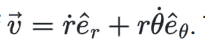

In [ ]:
#2B.10
x = -12
y = -5
er = -5
et = 0
t = 2

r0 = np.sqrt(x**2+y**2)
rf = r0 + er*t

cos = x/r0
sin = y/r0

xf = rf*cos
yf = rf*sin
print(xf,yf)

-2.769230769230769 -1.153846153846154


In [ ]:
#2B.11
-2*np.cos(3)+8

9.97998499320089

In [ ]:
#3A.2
import numpy as np

v = 3
F = 8
rho = 70

m = F*rho/v**2
print(m)

62.22222222222222


In [ ]:
#3A.5
import numpy as np
F = np.array([42,-62])
m = 6
g = np.array([0,-9.8])

a = F/m + g
print(a)

[  7.         -20.13333333]


In [ ]:
#3A.7
import numpy as np
from sympy import *

t = symbols('t', real = True)
r = Matrix([2*t**2 + t + 2, 2*t, 0])
t_v = 2

v = diff(r,t)
a = diff(v,t)

vsub = v.subs(t,t_v)
vmag = vsub.norm().evalf()
et = vsub/vmag
asub = a.subs(t,t_v)
at = asub.dot(et)
an = asub - at*et
amag = sqrt(an[0]**2+an[1]**2)
en = an/amag

print(en.evalf())

Matrix([[0.216930457818656], [-0.976187060183953], [0]])


In [ ]:
#3A.7 公式法，直接找到et
import numpy as np
from sympy import *

t = symbols('t', real = True)
r = Matrix([2*t**2 + t + 2, 2*t, 0])
t_v = 2

v = r.diff(t)
a = r.diff(t).diff(t)

vmag = v.norm().evalf()
et = v/vmag

up = et.diff(t)
down = et.diff(t).norm()

en = (up/down).subs(t,t_v).evalf()
print(en)

Matrix([[0.216930457818656], [-0.976187060183953], [0]])


In [ ]:
# 3A.8
import numpy as np
from sympy import *

x = symbols('x', real = True)
m = 4
y = 2*sin(x)
vx = 1
g = -9.8
x_v = 7

yp = y.diff(x)
ypp = y.diff(x).diff(x)

vy = vx * yp
v = Matrix([vx, vy])


ax = 0  
ay = vx**2 * ypp
a = Matrix([ax, ay])


F = m*a - Matrix([0, m*g]) #克服了重力才达到的a，所以实际上是把mg这一项给加上了，会变得更大

F = F.subs(x, x_v).evalf()
print(F)

Matrix([[0], [33.9441072102497]])


In [ ]:
# 3B.2
import numpy as np
from sympy import *

t = symbols('t', real = True)
s = -3*t**2 - t
t_v = 2
rho = 7

v = s.diff(t).subs(t,t_v).evalf()
at = s.diff(t).diff(t).subs(t,t_v).evalf()

an = v**2/rho #法向加速度为 v^2/rho

a = sqrt(at**2+an**2)
print(a)

24.8772496675257


In [ ]:
# 3B.3 读图求斜率即可，因为为切向运动，只有et方向

In [ ]:
# 3B.4
from sympy import *
import numpy as np

v = Matrix([0,34,3]) # in polar basis
a = Matrix([-34,68,-9]) # in polar basis

v_mag = v.norm().evalf()
down = a.cross(v).norm().evalf()

rho = v_mag**3/down

# 奇妙的推论，rho=|v|**3/|aXv| 或者是 v^2/an？
print(rho)


31.3691369955211


In [ ]:
# 3B.5 有两个方向，et方向求斜率，en方向用公式
v = 9
pho = 16

en = v**2/pho
et = 1/1

a = sqrt(en**2+et**2)
print(a)

# 题目中说a与v的夹角为theta，那么可以视作，a与at的夹角为theta
theta = 2.75
at = 2/(9-15)
a = at/np.cos(theta)
print(a)

5.16032036311700
0.3606323439592476


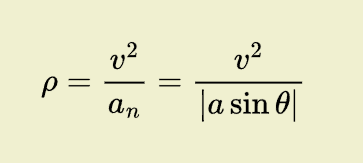<br>
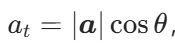

In [ ]:
# 3B.6
import numpy as np
from sympy import *

t = symbols('t', real = True)
r = Matrix([2 - t, -3*t**2 + 3*t - 2, 0])
t_v = 1

v = r.diff(t)
a = r.diff(t,2)

et = v/v.norm()
en = et.diff(t)/(et.diff(t)).norm()

k = r.diff(t).cross(r.diff(t,2)).norm()/(r.diff(t).norm())**3
rho = 1/k

position = r.subs(t,t_v)
ans = position + rho*en
print(ans.subs(t,t_v).evalf())

Matrix([[6.00000000000000], [-3.66666666666667], [0]])


In [ ]:
# 3B.7逐步如下
import numpy as np
from sympy import *

x = symbols('x', real = True)

m = 3
y = -4*cos(3*x)
g = -9.8
x_v = 5
vMag = 2
vDot = 5

yp = y.diff(x).subs(x,x_v).evalf()
ypp = y.diff(x).diff(x).subs(x,x_v).evalf()

#曲率半径有3种计算方式，从r出发，从xy出发，从y出发，看题目给什么条件

k = abs(ypp)/(1+yp**2)**(3/2)
rho = 1/k

sp = vMag
spp = vDot

at = -spp
an = sp**2/rho
#要注意符号！！！！减速还是加速

def equations(vars):
    vx, vy = vars
    eq1 = vx**2+vy**2-vMag**2
    eq2 = yp - vy/vx
    return [eq1,eq2]
ig = [-1,-1] #设的时候要注意速度方向，不然有可能错
v = fsolve(equations,ig)
v = Matrix([v[0],v[1]])

et = v/v.norm()
en = Matrix([-et[1],et[0]])
print(et,en,ypp)

i = at*et[0]+an*en[0]
j = at*et[1]+an*en[1]
print(i*m,(j-g)*m)

Matrix([[-0.127108938223977], [-0.991888762827553]]) Matrix([[0.991888762827553], [-0.127108938223977]]) -27.3487648629176
2.57514761108237 44.1926625154602


In [ ]:
# 4A.2
from sympy import *

rPQ = Matrix([1, 4, 0])
vP = Matrix([8, 2, 0])
vQ = Matrix([-12,   7,   0])

x = symbols('x', real = True)
w = Matrix([0,0,x])
ans = solve(vQ-vP-w.cross(rPQ),x)
print(ans)

{x: 5}


In [ ]:
# 4A.3
from sympy import *

rPQ = Matrix([2, 3, 0])
vP = Matrix([2, 4, 0])
omega = Matrix([ 0,  0, -1])

vQ = vP + omega.cross(rPQ)
print(vQ)

Matrix([[5], [2], [0]])


In [ ]:
# 4A.4
from sympy import *

omega = Matrix([0, 0, 0])
alpha = Matrix([ 0,  0, -1])
rPQ = Matrix([3, 0, 0])
aP = Matrix([-4, -5,  0])

aQ = aP + alpha.cross(rPQ) + omega.cross(omega.cross(rPQ))
print(aQ)

Matrix([[-4], [-8], [0]])


In [ ]:
# 4A.6
from sympy import *

w1, w2 = symbols('w1 w2')
rPA = Matrix([1, 2, 0])
rQA = Matrix([-2, -3,  0])
vP = Matrix([ 0, -1,  0])
vQ = Matrix([-1,  2,  0])

omega1 = Matrix([0,0,w1])
omega2 = Matrix([0,0,w2])

vA_PA = vP + omega1.cross(rPA)
vA_QA = vQ + omega2.cross(rQA)

eq1 = Eq(vA_PA[0], vA_QA[0])
eq2 = Eq(vA_PA[1], vA_QA[1])  

sol = solve((eq1, eq2), (w1, w2))
print(sol)

vA = vA_PA.subs(sol)
print(vA)

{w1: -7, w2: 5}
Matrix([[14], [-8], [0]])


In [ ]:
# 4A.7
from sympy import *

rPQ = Matrix([3, 0, 0])
vP = Matrix([-1, -2,  0])

u = Matrix([-1/sqrt(2),1/sqrt(2),0])
wz = symbols("wz")
w = Matrix([0,0,wz])

mag = symbols("mag")
q = mag*u
vQ = vP + w.cross(rPQ)

eq1 = Eq(q[0],vQ[0])
eq2 = Eq(q[1],vQ[1])

sol = solve((eq1,eq2),(wz,mag))

vq = vQ.subs(sol)
print(sol,vq.norm().evalf())

{mag: sqrt(2), wz: 1} 1.41421356237310


In [10]:
# 4A.8
from sympy import *

rOP = Matrix([-1, -2,  0])
rPQ = Matrix([12,  4,  0])
omega1 = Matrix([ 0,  0, 36])
omega2 = Matrix([0, 0, 3])
vP = Matrix([ 72, -36,   0])
vQ = Matrix([60,  0,  0])
alpha2 = Matrix([0, 0, 1])

a1 = symbols('a1')
alpha1 = Matrix([0,0,a1])

aP = alpha1.cross(rOP) + omega1.cross(omega1.cross(rOP))
aQ = aP + alpha2.cross(rPQ) + omega2.cross(omega2.cross(rPQ))

ans = solve(aQ[1],a1)
print(ans)
aq = aQ.subs(a1,ans[0])
print(aq)
ap = aP.subs(a1,ans[0])
print(ap)

[2568]
Matrix([[6320], [0], [0]])
Matrix([[6432], [24], [0]])


In [ ]:
# 4A.8 变式
from sympy import *

rOP = Matrix([2, 1, 0])
rPQ = Matrix([-2,  8,  0])
omega1 = Matrix([ 0,  0, 24])
omega2 = Matrix([ 0,  0, -3])
vP = Matrix([-24,  48,   0])
vQ = Matrix([ 0, 54,  0])
aP = Matrix([    6, -2892,     0])

a2 = symbols('a2')
alpha2 = Matrix([0,0,a2])
aQ = aP + alpha2.cross(rPQ) + omega2.cross(omega2.cross(rPQ))
ans = solve(aQ[0],a2)
print(ans)
aq = aQ.subs(a2,ans[0])
print(aq)


[3]
Matrix([[0], [-2970], [0]])


In [ ]:
# 4B.2
from sympy import *

rOP = Matrix([2, 1, 0])
rPQ = Matrix([ 0, -1,  0])
omega1 = Matrix([0, 0, 2])
omega2 = Matrix([ 0,  0, -1])
alpha1 = Matrix([0, 0, 3])
alpha2 = Matrix([0, 0, 3])

ap = alpha1.cross(rOP) + omega1.cross(omega1.cross(rOP))
aq = ap + alpha2.cross(rPQ) + omega2.cross(omega2.cross(rPQ))

print(ap,aq)

Matrix([[-11], [2], [0]]) Matrix([[-8], [3], [0]])


In [8]:
# 4B.3
from sympy import *

rOP = Matrix([-1,  3,  0])
rPQ = Matrix([1, 0, 0])
vQ = Matrix([3, 0, 0])

w1,w2 = symbols('w1 w2')
omega1 = Matrix([0,0,w1])
omega2 = Matrix([0,0,w2])

vp = omega1.cross(rOP)
vq = vp + omega2.cross(rPQ)
ans = solve(vq - vQ,w1,w2)

print(ans)

{w1: -1, w2: -1}


In [14]:
# 4B.4
from sympy import *

l = 6.0
aPMag = 3.0
thetaP = 62.0 # in degrees
aQMag = 3.0
thetaQ = 43.0 # in degrees

thetaP = rad(thetaP)
thetaQ = rad(thetaQ)

# 计算角速度w的时候要计算向心部分的加速度
aPn = aPMag*cos(thetaP)
aQn = -aQMag*cos(thetaQ) #但是这里又有一个负号

omega = symbols('omega')
ans1 = solve(aPn - aQn - omega**2*l,omega) #这里确定一个方向为正即可，反正就是相反数
print(ans1) #答案只要magnitude

# 计算角加速度a的时候要计算切向加速度
aPt = aPMag*sin(thetaP)
aQt = aQMag*sin(thetaQ)

alpha = symbols('alpha')
ans2 = solve(aPt + aQt - alpha*l,alpha) #此处的正负号为顺时针就为负，逆时针为正，需要记得修改
print(ans2)

[-0.774862976404558, 0.774862976404558]
[0.782472976460713]


In [ ]:
# 4B.5
from sympy import *

rAB = Matrix([1, 0, 0])
rBC = Matrix([0, 1, 0])
rAD = Matrix([-1,  2,  0])
rDC = Matrix([ 2, -1,  0])
omega1 = Matrix([0, 0, 2])

w2z,w3z = symbols('w2z,w3z')
omega2 = Matrix([0,0,w2z])
omega3 = Matrix([0,0,w3z])

#从两个路径出发算同一点的速度以此为方程列式子
vc1 = omega2.cross(rBC)
vd = omega1.cross(rAD)
vc2 = vd + omega3.cross(rDC)

eq1 = Eq(vc1[0],vc2[0])
eq2 = Eq(vc1[1],vc2[1])
ans = solve((eq1,eq2),(w2z,w3z))
print(ans)

{w2z: 3, w3z: 1}


In [ ]:
# 4B.9
from sympy import *

R = 0.10
v1 = 4.60
theta = 47.00 # in degrees

theta = rad(theta)

w2 = symbols('w2')
omega2 = Matrix([0,0,w2])
r = Matrix([R*cos(theta),R*sin(theta),0])

v1 = Matrix([v1,0,0])

vpt = omega2.cross(r)
ans = solve(vpt[0]-v1[0],w2)
print(ans)


Matrix([[-0.1*w2*sin(0.261111111111111*pi)], [0.1*w2*cos(0.261111111111111*pi)], [0]])
[-62.8970632105354]


In [ ]:
# 5A.2
from sympy import *

r1 = 9
r2 = 7
r3 = 6
omega3z = 4

# omega3z = -r4/r3*omega4z
omega2z = -r3/r2*omega3z
omega1z = -r2/r1*omega2z

# omega2z = -r1/r2*omega1z
# omega3z = -r2/r3*omega2z
# omega4z = -r3/r4*omega3z

print(omega1z)

2.6666666666666665


In [ ]:
# 5A.4
import numpy as np
from sympy import *

x, y = symbols('x, y')

rho = 3
y1 = 2*x**2 - 4*x - 3
y2 = -x**2 - 4*x + 14
x1 = 1
x2 = 2

A = integrate(abs(y2)+abs(y1),(x,x1,x2))
m = A*rho
print(m.evalf())

30.0000000000000


In [ ]:
# 5A.6
from sympy import *

r1 = 9
r2 = 5
r3 = 6
r4 = 8
aPMag = 23
alpha2Mag = 2

alpha1Mag = r2/r1*alpha2Mag
at1 = alpha1Mag*r1
an1 = sqrt(aPMag**2 - at1**2)

omega1 = sqrt(an1/r1)
omega3 = r1/r3*omega1
print(-omega3)

-2.27553923154535


In [7]:
# 5B.2
from sympy import *

m1 = 3
m2 = 3
m3 = 3
r2 = Matrix([0, 3, 0])
r3 = Matrix([ 6, -4,  0])
rC = Matrix([-12,   3,   0])

x,y,z = symbols('x y z')
r1 = Matrix([x,y,z])

rc = (m1*r1 + m2*r2 + m3*r3)/(m1+m2+m3)
ans = solve(rc-rC,x,y,z)
print(ans)

{x: -42, y: 10, z: 0}


In [ ]:
# 5B.3
from sympy import *

w = 2
l1 = 5
rho1 = 9
l2 = 5
rho2 = 5
l3 = 5
rho3 = 8

m1 = w*l1*rho1
m2 = w*l2*rho2
m3 = w*l3*rho3

x1 = l1/2
x2 = l2/2 + l1
x3 = l3/2 + l1 + l2

xc = (m1*x1 + m2*x2 + m3*x3)/(m1+m2+m3)

I1 = m1*(l1**2+w**2)/12 + m1*x1**2
I2 = m2*(l2**2+w**2)/12 + m2*x2**2
I3 = m3*(l3**2+w**2)/12 + m3*x3**2

I_side = I1 + I2 + I3 #平移到边缘

Ic = I_side - (m1+m2+m3)*xc**2 #再平移回中心

print(Ic)


4770.303030303032


In [ ]:
# 5B.4 P点在矩形的角落上
# 先对矩形分析
m3 = 3
a3 = 3
b3 = 4
I3 = m3*(a3**2+b3**2)/3

# 对杆子分析
m2 = 2
L = 4
Icm2 = m2*L**2/12
d2 = sqrt(2**2+1.5**2)
I2 = Icm2 + m2*d2**2

# 圆盘
m1 = 4
r = 1
Icm1 = m1*r**2/2
d1 = sqrt(5**2+1.5**2)
I1 = Icm1 + m1*d1**2

I = I1+I2+I3
print(I)

151.166666666667


In [16]:
# 5B.5
import numpy as np
from sympy import *

x, y = symbols('x, y')

rho = 7
y1 = -x**2 - 2
y2 = 2*x**2 + 1
x1 = 0
x2 = 1

# 定义微元
# 垂直条带的高度 h = y2 - y1
# 质量微元 dm = rho * (y2 - y1) * dx
dm_dx = rho * (y2 - y1)

# 1. 计算总质量 (Mass)
m = sp.integrate(dm_dx, (x, x1, x2))

# 2. 计算质心坐标 (Center of Mass)
# 对 y 轴的静矩 M_y
M_y = sp.integrate(x * dm_dx, (x, x1, x2))
X_c = M_y / m

# 对 x 轴的静矩 M_x = integral( rho/2 * (y2^2 - y1^2) )
M_x = sp.integrate((rho / 2) * (y2**2 - y1**2), (x, x1, x2))
Y_c = M_x / m

# 3. 计算绕原点的转动惯量 (Moments of Inertia about Origin)
# 绕 y 轴的转动惯量 I_y
I_y = sp.integrate(x**2 * dm_dx, (x, x1, x2))

# 绕 x 轴的转动惯量 I_x = integral( rho/3 * (y2^3 - y1^3) )
I_x = sp.integrate((rho / 3) * (y2**3 - y1**3), (x, x1, x2))

# 原点处的极转动惯量 I_O
I_O = I_x + I_y

# 4. 使用平行轴定理计算绕质心的转动惯量
# I_C = I_O - m * (X_c^2 + Y_c^2)
I_C = I_O - m * (X_c**2 + Y_c**2)

# --- 打印结果 ---
print("-" * 30)
print(f"质量 (m): {m} kg")
print(f"质心 X 坐标 (X_c): {X_c} m")
print(f"质心 Y 坐标 (Y_c): {Y_c} m")
print("-" * 30)
print(f"绕 x 轴转动惯量 (I_x): {I_x}")
print(f"绕 y 轴转动惯量 (I_y): {I_y}")
print(f"绕原点总转动惯量 (I_O): {I_O}")
print("-" * 30)
print(f"绕质心转动惯量精确分数 (I_C): {I_C}")
print(f"绕质心转动惯量近似小数 (I_C): {I_C.evalf():.4f} kg·m^2")

------------------------------
质量 (m): 28 kg
质心 X 坐标 (X_c): 9/16 m
质心 Y 坐标 (Y_c): -0.300000000000000 m
------------------------------
绕 x 轴转动惯量 (I_x): 46.4000000000000
绕 y 轴转动惯量 (I_y): 56/5
绕原点总转动惯量 (I_O): 57.6000000000000
------------------------------
绕质心转动惯量精确分数 (I_C): 46.2206250000000
绕质心转动惯量近似小数 (I_C): 46.2206 kg·m^2
